Trying different type of models for LST estimation

## General paths, libraries and functions

In [1]:
!pip install seaborn
!pip install statsmodels
!pip install rasterstats


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [2]:
# user-defined paths
base_dir = '../../../datos-notebooks/2.global-data-bologna/'
census_areas_name = 'sezioni-di-censimento-anno-2011.geojson'
trained_models_path = '../../../datos-notebooks/1.HR-data-bologna/1.4.LST-prediction/' # modeles trained with HR data

In [3]:
# inputs

# LST
lst_clipped_path = os.path.join(base_dir, 'LST/LST_clipped_celsius.tif') #values out of bound are nan
# vectors
census_areas_path = os.path.join(base_dir, census_areas_name)
# variables - Best results (pearson correlation with LST) for window size -- same as used in HR data
ndwi_1_path = os.path.join(base_dir, 'land-cover/moving-windows/ndwi/Class_1_window61.tif')
ndvi_1_path = os.path.join(base_dir, 'land-cover/moving-windows/ndvi/Class_1_window13.tif')
ndvi_0p5_path = os.path.join(base_dir, 'land-cover/moving-windows/ndvi/Class_0p5_window13.tif')
veg_vol_path = os.path.join(base_dir, 'objects-height/moving-windows/tree-volume/trees_window15.tif')
veg_height_path = os.path.join(base_dir, 'objects-height/moving-windows/tree-height/trees_height_window15.tif')
built_vol_path = os.path.join(base_dir, 'objects-height/moving-windows/building-volume/buildings_window13.tif')
built_area_path = os.path.join(base_dir, 'objects-height/moving-windows/building-area/building_area_window13.tif')
building_height_path = os.path.join(base_dir, 'objects-height/moving-windows/building-height/building_height_window19.tif')
mean_elev_path = os.path.join(base_dir, 'topography/moving_windows/elev_mean/elev_mean_win111.tif')
mean_slope_path = os.path.join(base_dir, 'topography/moving_windows/slope_mean/slope_mean_win19.tif')
northness_path = os.path.join(base_dir, 'topography/moving_windows/northness/northness_win71.tif')


In [13]:
# output directorys
lst_prediction_folder = os.path.join(base_dir, 'LST-prediction/')
os.makedirs(lst_prediction_folder, exist_ok=True)
standarized_folder_path = os.path.join(lst_prediction_folder, 'standarized_variables')

## Dataset preparation

### mask rasters to city boundary

In [5]:
with rasterio.open(lst_clipped_path) as src:
    lst = src.read(1)

lst_mask = np.isnan(lst)

# mask values out of city boundary
ndwi_1 = np.where(lst_mask, np.nan, rasterio.open(ndwi_1_path).read(1).astype("float32"))
ndvi_1 = np.where(lst_mask, np.nan, rasterio.open(ndvi_1_path).read(1).astype("float32"))
ndvi_0p5 = np.where(lst_mask, np.nan, rasterio.open(ndvi_0p5_path).read(1).astype("float32"))
veg_vol = np.where(lst_mask, np.nan, rasterio.open(veg_vol_path).read(1).astype("float32"))
veg_height = np.where(lst_mask, np.nan, rasterio.open(veg_height_path).read(1).astype("float32"))
built_vol = np.where(lst_mask, np.nan, rasterio.open(built_vol_path).read(1).astype("float32"))
built_area = np.where(lst_mask, np.nan, rasterio.open(built_area_path).read(1).astype("float32"))
built_height = np.where(lst_mask, np.nan, rasterio.open(building_height_path).read(1).astype("float32"))
mean_elev = np.where(lst_mask, np.nan, rasterio.open(mean_elev_path).read(1).astype("float32"))
mean_slope = np.where(lst_mask, np.nan, rasterio.open(mean_slope_path).read(1).astype("float32"))
northness = np.where(lst_mask, np.nan, rasterio.open(northness_path).read(1).astype("float32"))

rasters_masked = {
    #"Agua": ndwi_1,
    "Vegetación densa": ndvi_1,
    "Vegetación dispersa": ndvi_0p5,
    #"Volumen de vegetación": veg_vol,
    #"Volumen construido": built_vol,  # Excluded due to duplicated information
    "Área construida": built_area,
    "Altura de edificación": built_height,
    "Elevación": mean_elev,
    "Pendiente": mean_slope,
    "Orientación norte": northness,
    "Altura de vegetación": veg_height
}

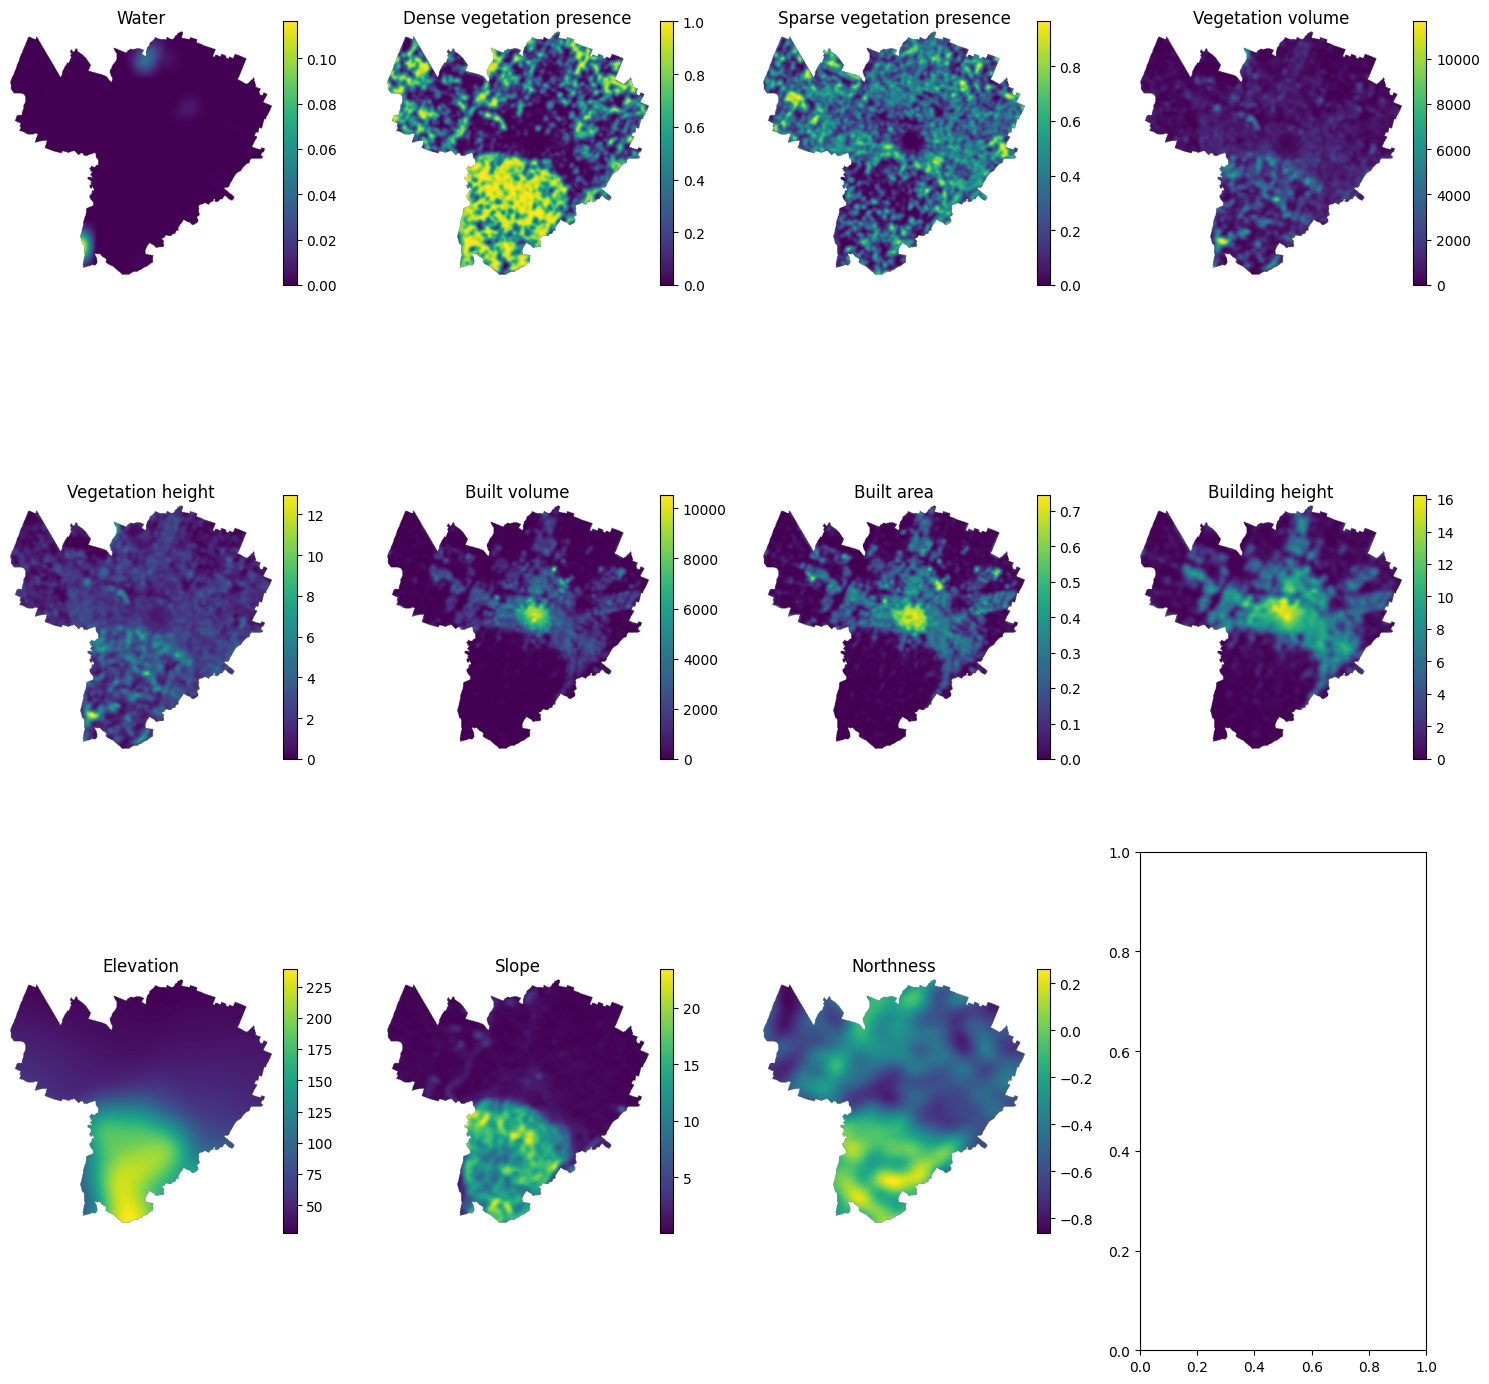

In [7]:
#plot masked rasters 

fig, axes = plt.subplots(3, 4, figsize=(15, 15))

for ax, (name, data) in zip(axes.flat, rasters_masked.items()):

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

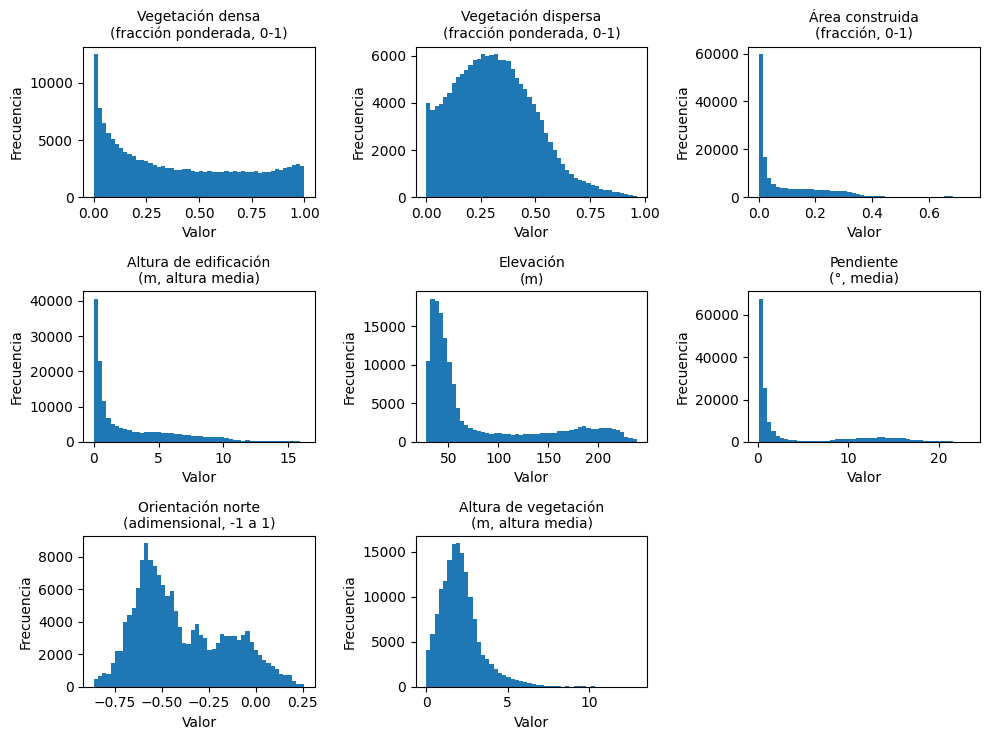

In [11]:
# Plot histograms of masked rasters

titles = {
    "Vegetación densa": "Vegetación densa\n(fracción ponderada, 0-1)",
    "Vegetación dispersa": "Vegetación dispersa\n(fracción ponderada, 0-1)",
    "Área construida": "Área construida\n(fracción, 0-1)",
    "Altura de edificación": "Altura de edificación\n(m, altura media)",
    "Elevación": "Elevación\n(m)",
    "Pendiente": "Pendiente\n(°, media)",
    "Orientación norte": "Orientación norte\n(adimensional, -1 a 1)",
    "Altura de vegetación": "Altura de vegetación\n(m, altura media)",
}

fig, axes = plt.subplots(3, 3, figsize=(10, 7.5))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, arr) in enumerate(rasters_masked.items()):
    # Plot histogram using already-masked arrays
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(titles[name], fontsize=10)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

# Hide unused subplot (9 slots, 8 variables)
for j in range(i + 1, 9):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### standarize variables - mean:0, std:1

In [9]:
os.makedirs(standarized_folder_path, exist_ok=True)

In [10]:
# Z-score standardization for regression predictors

def standardize_array(arr, profile, out_path):
    mean = np.nanmean(arr)
    std = np.nanstd(arr)
    z = (arr - mean) / std

    profile.update(dtype='float32')

    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(z.astype('float32'), 1)

In [11]:
# Apply standarization
with rasterio.open(lst_clipped_path) as src:
    profile = src.profile.copy()
    
standardize_array(ndwi_1, profile, os.path.join(standarized_folder_path, 'NDWI_1_z.tif'))
standardize_array(ndvi_1, profile, os.path.join(standarized_folder_path, 'NDVI_1_z.tif'))
standardize_array(ndvi_0p5, profile, os.path.join(standarized_folder_path, 'NDVI_0p5_z.tif'))
standardize_array(veg_vol, profile, os.path.join(standarized_folder_path, 'VEG_VOL_z.tif'))
standardize_array(veg_height, profile, os.path.join(standarized_folder_path, 'VEG_HEIGHT_z.tif'))
standardize_array(built_vol, profile, os.path.join(standarized_folder_path, 'BUILT_VOL_z.tif'))
standardize_array(built_area, profile, os.path.join(standarized_folder_path, 'BUILT_AREA_z.tif'))
standardize_array(built_height, profile, os.path.join(standarized_folder_path, 'BUILDING_HEIGHT_z.tif'))
standardize_array(mean_elev, profile, os.path.join(standarized_folder_path, 'ELEV_z.tif'))
standardize_array(mean_slope, profile, os.path.join(standarized_folder_path, 'SLOPE_z.tif'))
standardize_array(northness, profile, os.path.join(standarized_folder_path, 'NORTH_z.tif'))

In [14]:
std_rasters_paths = {
    #"Agua": os.path.join(standarized_folder_path, "NDWI_1_z.tif"),
    "Vegetación densa": os.path.join(standarized_folder_path, "NDVI_1_z.tif"),
    "Vegetación dispersa": os.path.join(standarized_folder_path, "NDVI_0p5_z.tif"),
    #"Volumen de vegetación": os.path.join(standarized_folder_path, "VEG_VOL_z.tif"),
    #"Volumen construido": os.path.join(standarized_folder_path, "BUILT_VOL_z.tif"),  # Excluded due to duplicated information
    "Área construida": os.path.join(standarized_folder_path, "BUILT_AREA_z.tif"),
    "Altura de edificación": os.path.join(standarized_folder_path, "BUILDING_HEIGHT_z.tif"),
    "Elevación": os.path.join(standarized_folder_path, "ELEV_z.tif"),
    "Pendiente": os.path.join(standarized_folder_path, "SLOPE_z.tif"),
    "Orientación norte": os.path.join(standarized_folder_path, "NORTH_z.tif"),
    "Altura de vegetación": os.path.join(standarized_folder_path, "VEG_HEIGHT_z.tif")    
}

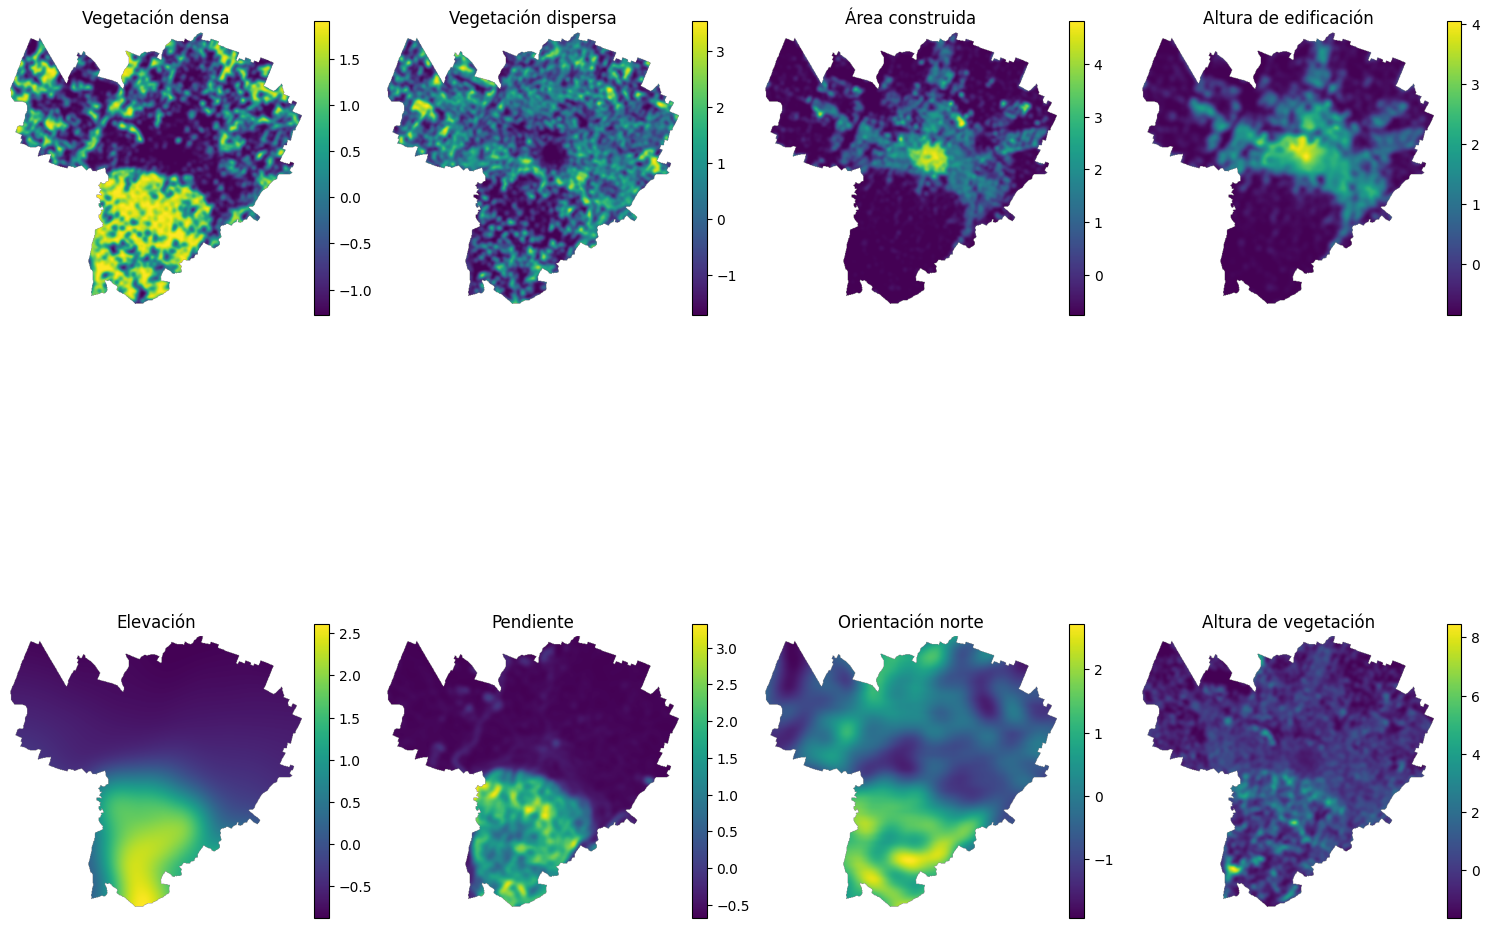

In [23]:
#plot cropped and standardized rasters

fig, axes = plt.subplots(2, 4, figsize=(15, 15))

for ax, (name, path) in zip(axes.flat, std_rasters_paths.items()):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)

    img = ax.imshow(data, cmap='viridis')
    ax.set_title(name)
    ax.axis('off')
    fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)


plt.tight_layout()
plt.show()

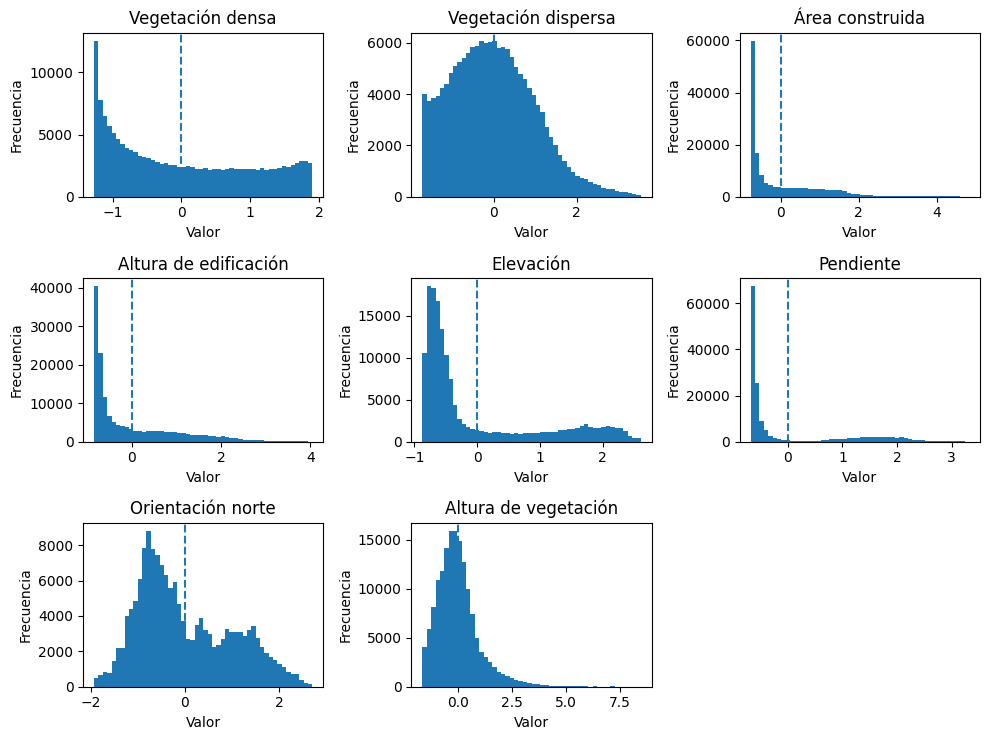

In [17]:

fig, axes = plt.subplots(3, 3, figsize=(10, 7.5))
axes = axes.flatten()  # Flatten to 1D for easy indexing

for i, (name, path) in enumerate(std_rasters_paths.items()):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata

    # Plot histogram
    axes[i].hist(arr[~np.isnan(arr)], bins=50)
    axes[i].set_title(name)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")
    axes[i].axvline(0, linestyle='--')
    
# Hide unused subplot (9 slots, 8 variables)
for j in range(i + 1, 9):
    axes[j].axis("off")



plt.tight_layout()
plt.show()

### stratified sampling of LST

In [19]:
rasters = {"LST": lst_clipped_path} # create dictionary with LST raster (not standardized)
rasters.update(std_rasters_paths) # add standardized rasters to the dictionary
#rasters.pop("Variable name", None) # to delete one variable if needed

In [20]:
rasters

{'LST': '../../../datos-notebooks/2.global-data-bologna/LST/LST_clipped_celsius.tif',
 'Vegetación densa': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\NDVI_1_z.tif',
 'Vegetación dispersa': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\NDVI_0p5_z.tif',
 'Área construida': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\BUILT_AREA_z.tif',
 'Altura de edificación': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\BUILDING_HEIGHT_z.tif',
 'Elevación': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\ELEV_z.tif',
 'Pendiente': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\SLOPE_z.tif',
 'Orientación norte': '../../../datos-notebooks/2.global-data-bologna/LST-prediction/standarized_variables\\NORTH_z.tif',
 'Altura de vegetación': '../../../datos-notebooks/2.gl

In [21]:
# Create bins
n_bins = 10

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

df = df.dropna() # Drop rows with NaN

df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False) # Create LST bins for stratification 

In [22]:
# Stratified sampling: 10% of each bin

sample_fraction = 0.1
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())


         LST  Vegetación densa  Vegetación dispersa  Área construida  \
0  33.068665          1.805667            -1.543948        -0.680931   
1  32.350883          1.306578            -1.178914        -0.760521   
2  34.319660          1.170327            -0.525631        -0.606843   
3  32.039841          1.720938            -1.398535        -0.747500   
4  34.459801          1.755697            -1.458189        -0.736775   

   Altura de edificación  Elevación  Pendiente  Orientación norte  \
0              -0.639537   1.053554   2.138849           0.457952   
1              -0.835348  -0.807058  -0.331841           1.143459   
2              -0.519815   0.793282   1.605314          -0.029866   
3              -0.804751   1.135746   2.745764           0.729048   
4              -0.723235   2.293686   2.339286           1.542432   

   Altura de vegetación  
0              2.041805  
1              2.086071  
2              1.681344  
3              2.027377  
4              0.60230

C:\Users\guada\AppData\Local\Temp\ipykernel_25988\4163941717.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('LST_bin', group_keys=False).apply(


In [23]:
# Show min, max and count of LST values in each bin

df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False) # Recreate bins for the sampled dataset

for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")

df_sampled = df_sampled.drop(columns=['LST_bin'])

Bin 0: min = 30.58, max = 34.56, count = 1565
Bin 1: min = 34.57, max = 36.29, count = 1565
Bin 2: min = 36.29, max = 37.56, count = 1566
Bin 3: min = 37.57, max = 38.56, count = 1565
Bin 4: min = 38.57, max = 39.43, count = 1564
Bin 5: min = 39.44, max = 40.22, count = 1570
Bin 6: min = 40.22, max = 40.95, count = 1560
Bin 7: min = 40.96, max = 41.74, count = 1566
Bin 8: min = 41.74, max = 42.86, count = 1562
Bin 9: min = 42.86, max = 51.39, count = 1564


### Descriptive statistics

In [24]:
# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

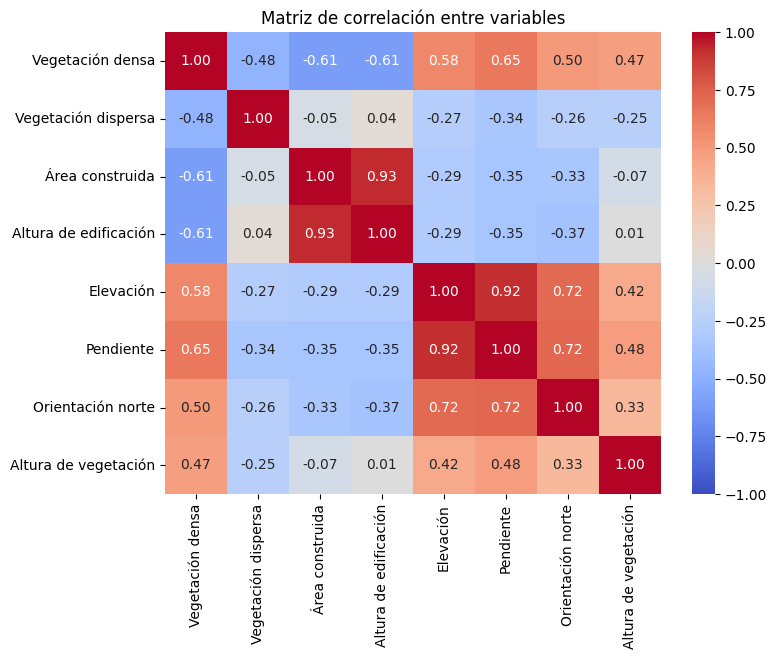

In [25]:
# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación entre variables")
plt.show()


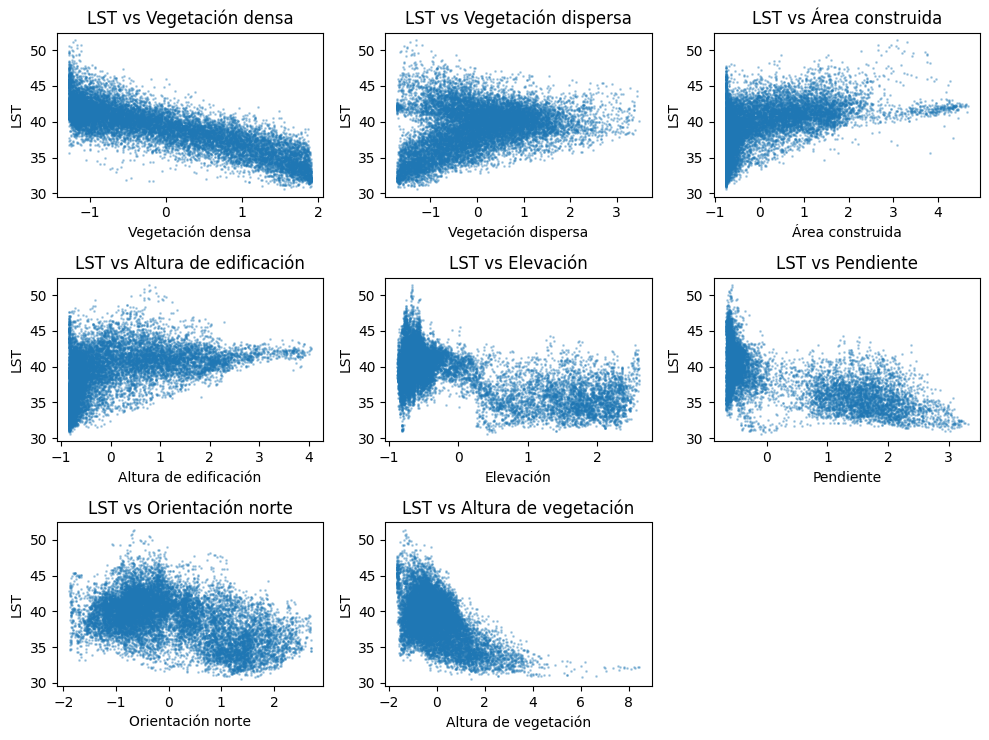

In [38]:
# Plot correlations: Variables vs LST

n_vars = len(X)

fig, axes = plt.subplots(3, 3, figsize=(10, 7.5))
axes = axes.flatten() 

for i, v in enumerate(X.columns):
    axes[i].scatter(X[v], y, s=1, alpha=0.3)
    axes[i].set_xlabel(v)
    axes[i].set_ylabel("LST")
    axes[i].set_title(f"LST vs {v}")
axes[i+1].axis("off")  # Hide the last unused subplot


plt.tight_layout()
plt.show()

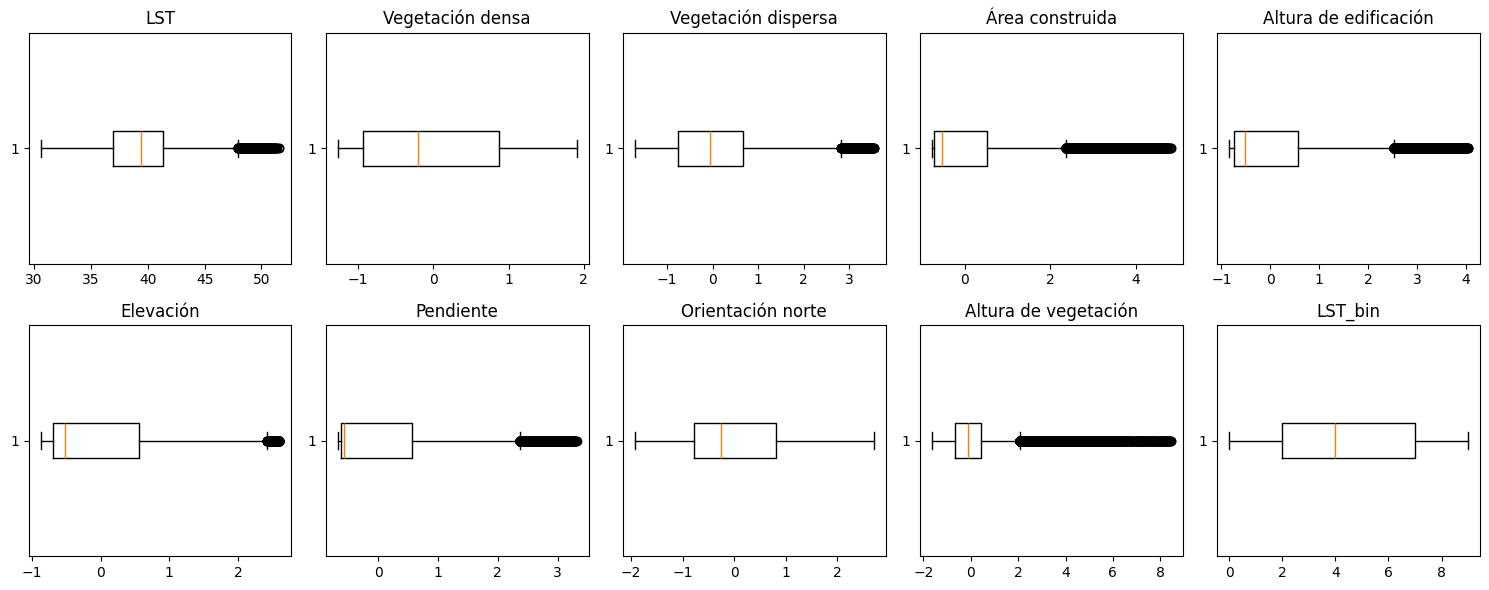

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, v in enumerate(df.columns[:10]):
    axes[i].boxplot(df[v], vert=False)
    axes[i].set_title(v)

for ax in axes[len(df.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Modelling

In [28]:
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=500,       # number of trees
    max_depth=None,         # no max depth
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)


,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Error metrics
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))
bias = np.mean(y_pred - y_test)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"Bias: {bias:.3f}")

R²: 0.913
RMSE: 0.926
MAE: 0.682
Bias: 0.019


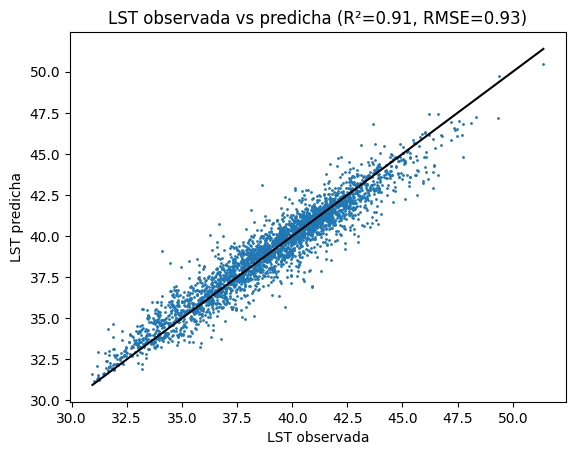

In [30]:
plt.figure()
plt.scatter(y_test, y_pred, s=1)  
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="black")
plt.xlabel("LST observada")
plt.ylabel("LST predicha")
plt.title(f"LST observada vs predicha (R²={r2:.2f}, RMSE={rmse:.2f})")
plt.show()

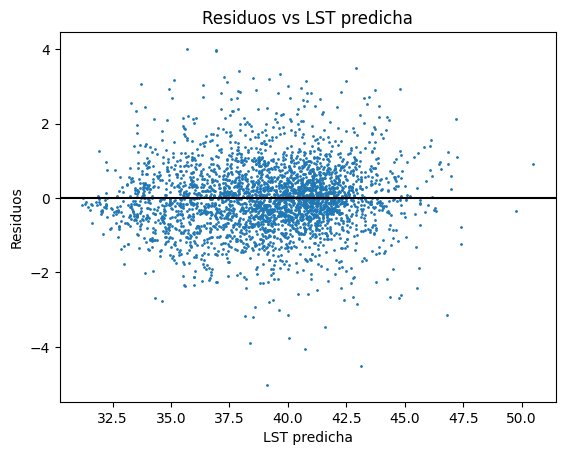

In [31]:
# Residuals plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals, s=1)
plt.axhline(0, color='black')
plt.xlabel("LST predicha")
plt.ylabel("Residuos")
plt.title("Residuos vs LST predicha")
plt.show()



In [32]:
# Variable importance
importances = rf_model.feature_importances_

# Create dataframe for sorting
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Print ordered results
for _, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.3f}")

Vegetación densa: 0.677
Elevación: 0.074
Altura de vegetación: 0.068
Vegetación dispersa: 0.052
Altura de edificación: 0.039
Área construida: 0.033
Orientación norte: 0.032
Pendiente: 0.024


## Applying RF model in all the city

In [33]:
print(X.columns.tolist())


['Vegetación densa', 'Vegetación dispersa', 'Área construida', 'Altura de edificación', 'Elevación', 'Pendiente', 'Orientación norte', 'Altura de vegetación']


In [34]:
# Predictor order (MUST match training)
predictor_order = ['Vegetación densa', 'Vegetación dispersa', 'Área construida', 'Altura de edificación', 'Elevación', 'Pendiente', 'Orientación norte', 'Altura de vegetación']


# Read rasters using 'rasters' dict
arrays = []
meta = None

for name in predictor_order:
    path = rasters[name]   # get path from existing dict
    with rasterio.open(path) as src:
        arr = src.read(1)
        arrays.append(arr)
        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=-1)  # (rows, cols, n_features)


# Mask nodata pixels
nodata_mask = np.any(np.isnan(stack), axis=-1)


# Reshape for model prediction
nrows, ncols, nbands = stack.shape
X_map = stack.reshape(-1, nbands)

valid = ~nodata_mask.ravel()
X_valid = X_map[valid]

# Predict LST
y_map = np.full(X_map.shape[0], np.nan)   # allocate output
y_map[valid] = rf_model.predict(X_valid) # calls the trained model

# Back to raster shape
lst_pred = y_map.reshape(nrows, ncols)

# Save raster
meta.update(dtype="float32", count=1, nodata=np.nan)

out_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(out_path, "w", **meta) as dst:
    dst.write(lst_pred.astype("float32"), 1)
    

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


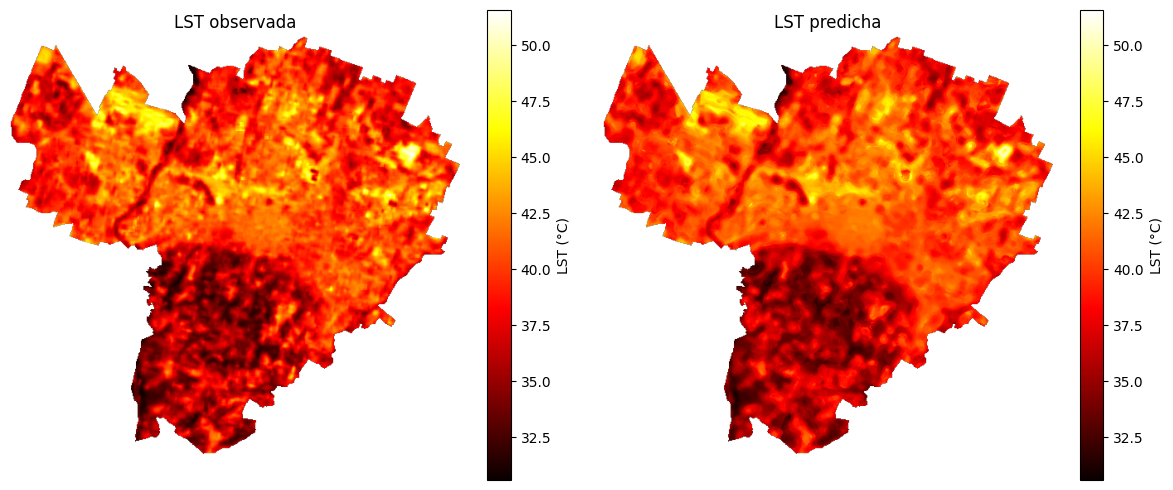

In [35]:
# Plot observed vs predicted LST

lst_predicted_path = os.path.join(lst_prediction_folder, "LST_predicted_RF.tif")

with rasterio.open(lst_clipped_path) as src:
    lst_observed = src.read(1)

with rasterio.open(lst_predicted_path) as src:
    lst_pred = src.read(1)
    
vmin = np.nanmin(lst_observed)
vmax = np.nanmax(lst_observed)

# Plot 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(lst_observed, vmin=vmin, vmax=vmax, cmap="hot")  # thermal colormap
plt.colorbar(label="LST (°C)")
plt.title("LST observada")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(lst_pred, vmin=vmin, vmax=vmax, cmap="hot")  # same colormap
plt.colorbar(label="LST (°C)")
plt.title("LST predicha")
plt.axis("off")

plt.tight_layout()
plt.show()
